In [89]:
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig6_hse')
figdir.mkdir(exist_ok=True)

In [2]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [3]:
def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(6):
        corr_dict[react_day] = {}
        for tt_corr_day in range(react_day+1,6):
       
            corr_dict[react_day][tt_corr_day] ={}
            days = [react_day, tt_corr_day]
            
            
            common_roi_mapping = u.common_rois_adjust(mouse, days)


            with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                hse_react = pickle.load(file)

            # trial matrix 
            # with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                # hse_tt_corr = pickle.load(file)
            hse_tt_corr = u.load_single_day(mouse, tt_corr_day, trial_mat_keys=['F_dff_nostop',], verbose=False)
                
            for key, coef  in zip(('fam', 'nov'), (-1,1)):
                corr_dict[react_day][tt_corr_day][key] = {}
                   

                # reactivation mask 
                react_mask = hse_react.post_reward_coactive_mask[common_roi_mapping[0,:],:][:, hse_react.lr==coef*hse_react.novel_arm].sum(axis=-1)>0
                
                trial_mask = hse_tt_corr.trial_info['LR'] == coef*hse_tt_corr.novel_arm
                tmat = hse_tt_corr.trial_matrices['F_dff_nostop'][trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                # tmat = hse_tt_corr.trial_mat[:, : , common_roi_mapping[1, :]][hse_tt_corr.trial_info['LR'] == coef*hse_tt_corr.novel_arm, :, :] 

                ## trial x trial correlation
                corr_mat = np.zeros((tmat.shape[0], tmat.shape[0], tmat.shape[-1]))
                for cell in range(tmat.shape[-1]):
                    _mat = np.corrcoef(tmat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                print(react_day, tt_corr_day, key, react_mask.sum())
                if react_mask.sum()>0:

                    corr_dict[react_day][tt_corr_day][key]['activated']=np.nanmean(np.nanmean(corr_mat[:,:, react_mask], axis=0), axis=0)
                    corr_dict[react_day][tt_corr_day][key]['activated_cell_argmax'] = np.nanargmax(np.nanmean(tmat[:,:,react_mask], axis=0),axis=0)

                    corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nanmean(np.nanmean(corr_mat[:,:, ~react_mask], axis=0), axis=0)
                    corr_dict[react_day][tt_corr_day][key]['nonactivated_cell_argmax'] = np.nanargmax(np.nanmean(tmat[:,:,~react_mask], axis=0),axis=0)
                else:
                    corr_dict[react_day][tt_corr_day][key]['activated']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['activated_cell_argmax'] = [np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['nonactivated']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['nonactivated_cell_argmax'] = [np.nan,]

                
    return corr_dict



In [4]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        corr_dict = predict_future_tt_stability(mouse)
        for i in range(5):
            for j in range(i+1,6):
                for ttype in ('fam', 'nov'):
                
                    activated_corr = corr_dict[i][j][ttype]['activated']
                    nonactivated_corr =  corr_dict[i][j][ttype]['nonactivated']
                    activated_cell_argmax = corr_dict[i][j][ttype]['activated_cell_argmax']
                    nonactivated_cell_argmax = corr_dict[i][j][ttype]['nonactivated_cell_argmax']
                    # print(hse_corr.shape)
                    
                    nanmask = np.isnan(np.array(activated_corr).flatten())
                    nanmask = np.array([nanmask,]).ravel()
                    if nanmask.shape[0]==1:
                        continue
                    

                    for corr, argmax in zip(activated_corr, activated_cell_argmax):
                        rows.append({'condition': cond,
                                    'mouse': mouse,
                                    'ttype': ttype,
                                    'hse_day': i,
                                    'tt_day': j,
                                    'activated': True,
                                    'tt_corr': corr,
                                    'cell_argmax': argmax,
                                    })
                        
                    for corr, argmax in zip(nonactivated_corr, nonactivated_cell_argmax):
                        rows.append({'condition': cond,
                                    'mouse': mouse,
                                    'ttype': ttype,
                                    'hse_day': i,
                                    'tt_day': j,
                                    'activated': False,
                                    'tt_corr': corr,
                                    'cell_argmax': argmax,
                                    })
                

                    
df = pd.DataFrame(rows)

4467331.1
4467331.1
0 1 fam 282


/tmp/ipykernel_257401/236712197.py:48: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['activated']=np.nanmean(np.nanmean(corr_mat[:,:, react_mask], axis=0), axis=0)
/tmp/ipykernel_257401/236712197.py:51: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nanmean(np.nanmean(corr_mat[:,:, ~react_mask], axis=0), axis=0)


0 1 nov 94
0 2 fam 261


/tmp/ipykernel_257401/236712197.py:48: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['activated']=np.nanmean(np.nanmean(corr_mat[:,:, react_mask], axis=0), axis=0)
/tmp/ipykernel_257401/236712197.py:51: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nanmean(np.nanmean(corr_mat[:,:, ~react_mask], axis=0), axis=0)


0 2 nov 90
0 3 fam 274


...

/tmp/ipykernel_257401/236712197.py:48: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['activated']=np.nanmean(np.nanmean(corr_mat[:,:, react_mask], axis=0), axis=0)
/tmp/ipykernel_257401/236712197.py:51: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nanmean(np.nanmean(corr_mat[:,:, ~react_mask], axis=0), axis=0)


3 5 fam 499
3 5 nov 0


/tmp/ipykernel_257401/236712197.py:48: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['activated']=np.nanmean(np.nanmean(corr_mat[:,:, react_mask], axis=0), axis=0)
/tmp/ipykernel_257401/236712197.py:51: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nanmean(np.nanmean(corr_mat[:,:, ~react_mask], axis=0), axis=0)


4 5 fam 423
4 5 nov 117


/tmp/ipykernel_257401/236712197.py:48: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['activated']=np.nanmean(np.nanmean(corr_mat[:,:, react_mask], axis=0), axis=0)
/tmp/ipykernel_257401/236712197.py:51: RuntimeWarning: Mean of empty slice
  corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nanmean(np.nanmean(corr_mat[:,:, ~react_mask], axis=0), axis=0)


In [5]:
df.to_pickle('/home/mplitt/shuffle_pkls/hse_react_results_dff.pkl')

In [6]:
with open('/home/mplitt/shuffle_pkls/hse_react_results_dff.pkl','rb') as file:
    df = pickle.load(file)

# plot events

In [93]:
def plot_single_trial_replay(hse, t):
    start, stop = hse.trial_start_inds[t], hse.teleport_inds[t]
    post_reward_bool = hse.post_reward_bool[start:stop]
    pop_coactivity_th = hse.pop_coactivity_th[start:stop]
    
    if post_reward_bool.sum()>0 and pop_coactivity_th.sum()>0:
        nov_sort = np.argsort(np.argmax(np.nanmean(hse.trial_mat[hse.trial_info['LR']==hse.novel_arm,:,:],axis=0),axis=0))
        fam_sort = np.argsort(np.argmax(np.nanmean(hse.trial_mat[hse.trial_info['LR']==-1*hse.novel_arm,:,:],axis=0),axis=0))
        # print(sort.shape)


        nov = hse.trial_info['LR'][t] == hse.novel_arm

        if nov:
            sort = nov_sort
        else:
            sort = fam_sort


        post_reward_coactive_mask = hse.post_reward_coactive_mask[sort,:]
        event_mask = post_reward_coactive_mask[:, start:stop].sum(axis=-1)>0
        cell_mask = hse.post_reward_activation_mask[sort,:][:, start:stop].sum(axis=-1)>0
        # sort = np.argsort(np.argmax())

        # spks = hse.spks[sort,:]
        spks = hse.post_reward_activation_mask[sort,:] #+ hse.trial_activation_mask[sort,:]
        f_dff = hse.spks[sort,:]
        spks_th = hse.spks_th[sort,:]

        

        fig = plt.figure(figsize=[10,5])
        gs = fig.add_gridspec(3,2, height_ratios = (3, 1, 1))
        # fig,ax = plt.subplots(3,1, sharex=True)

        hm_ax = fig.add_subplot(gs[0, 0])
        hm_ax.set_title(f'trial {t}, Novel = {nov}')
        x = np.arange(stop-start)




        # # activity
        hm_ax.imshow(f_dff[cell_mask, :][:,start:stop], 
                     aspect = 'auto', cmap='Greys', interpolation='none', vmin=0.05, vmax=.5)
        tmp_spks = spks[cell_mask, :][:, start:stop]
        for r in range(tmp_spks.shape[0]):
            c = np.argwhere(tmp_spks[r,:]==1).ravel()
            hm_ax.scatter(c, r*np.ones_like(c), color='red', zorder=10,s =5)


        ledges = np.argwhere(post_reward_bool[1:]>post_reward_bool[:-1])
        redges = np.argwhere(post_reward_bool[1:]<post_reward_bool[:-1])
        for ledge, redge in zip(ledges, redges):
            hm_ax.fill_betweenx([-.5,cell_mask.sum()-.5], ledge, redge+1, alpha = .3,  color='green')
        hm_ax.set_ylim([cell_mask.sum()-.5, -.5])
        hm_ax.set_yticks([])
        hm_ax.set_ylabel('Cells')
        

        speed_ax = fig.add_subplot(gs[1,0], sharex=hm_ax)
        
        
        speed_ax.set_ylabel('Speed')
        speed = sp.ndimage.gaussian_filter1d(hse.speed.ravel()[start:stop], 1)
        speed_ax.plot(x,speed)
        reward_ind = x[hse.reward.ravel()[start:stop]>0]
        if reward_ind.shape[0]==1:
            speed_ax.scatter(reward_ind,speed[reward_ind[0]],color='orange', zorder=10)
        elif reward_ind.shape[0]>1:
            speed_ax.scatter(reward_ind[0],speed[reward_ind[0]],color='orange', zorder=10)
            
        speed_bounds = [np.amin(speed)-5, np.amax(speed)+5]
        for ledge, redge in zip(ledges, redges):
            speed_ax.fill_betweenx(speed_bounds, ledge, redge+1, alpha = .3, zorder=-1, color='green')
        speed_ax.set_ylim(speed_bounds)

        pop_ax = fig.add_subplot(gs[2,0], sharex=hm_ax)
        
        for ledge, redge in zip(ledges, redges):
            pop_ax.fill_betweenx([-1,np.amax(hse.pop_coactivity_boxcar[start:stop])+2], ledge, redge+1, alpha = .3, zorder=-1, color='green')
        
        pop_ax.set_ylim([-1,np.amax(hse.pop_coactivity_boxcar[start:stop])+2])
        pop_ax.plot(hse.pop_coactivity_boxcar[start:stop], color='black')
        
        pop_ax.plot(np.arange(stop-start),hse.coactivity_thresh*np.ones([stop-start,]), color='red', alpha=.3)
        pop_ax.set_ylabel('Pop Activity')


        time = x/hse.frame_rate
        time = [str(int(t)) for t in time]
        pop_ax.set_xticks(x[::50], labels=time[::50])

        return fig, event_mask
    else:
        # print(f"No eligible stopping period on trial {t}")
        return None
    

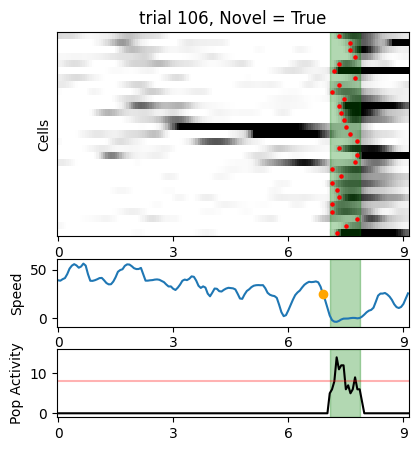

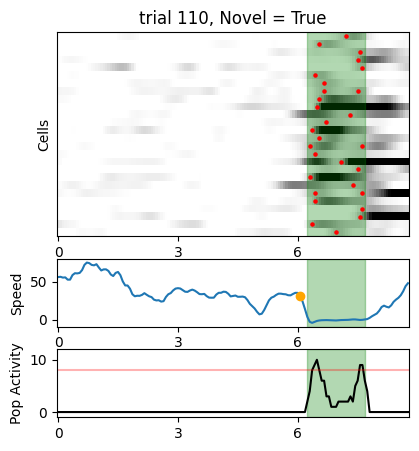

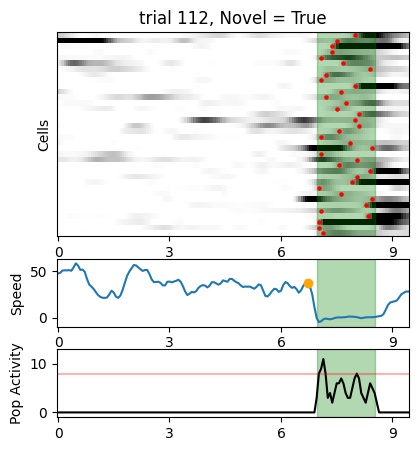

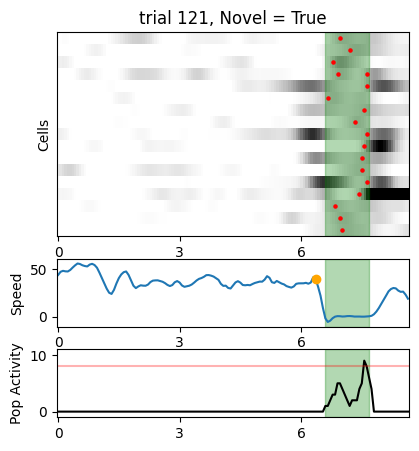

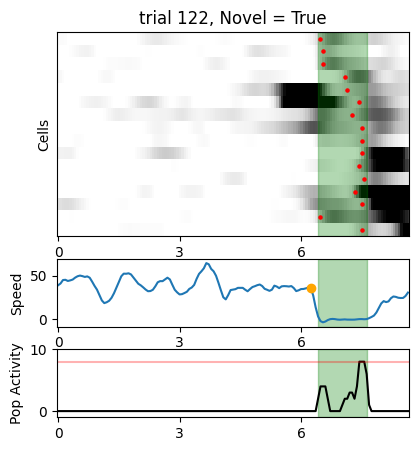

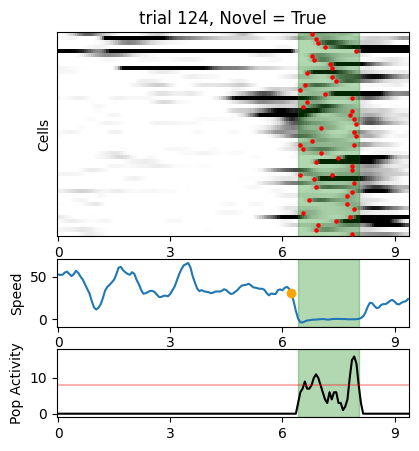

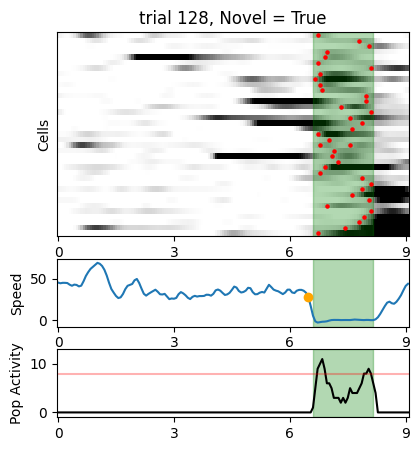

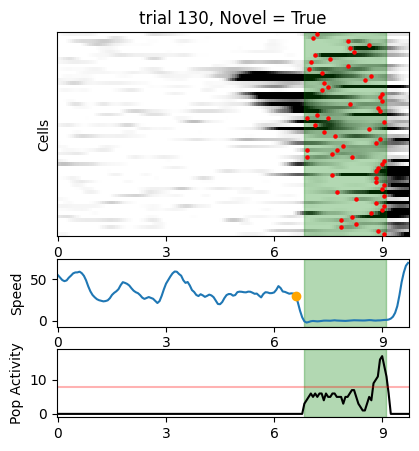

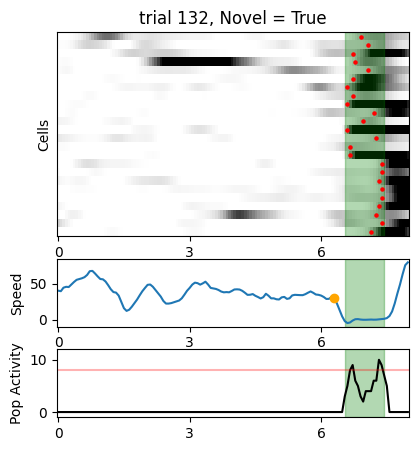

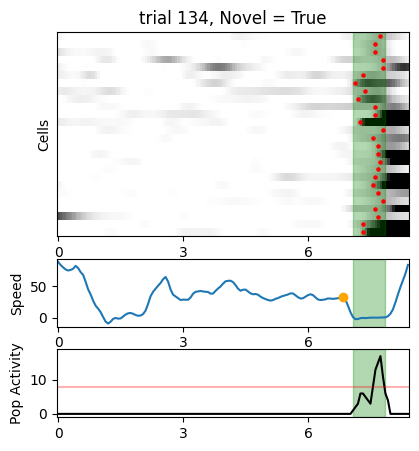

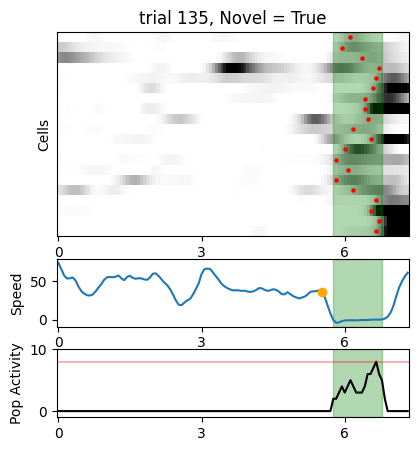

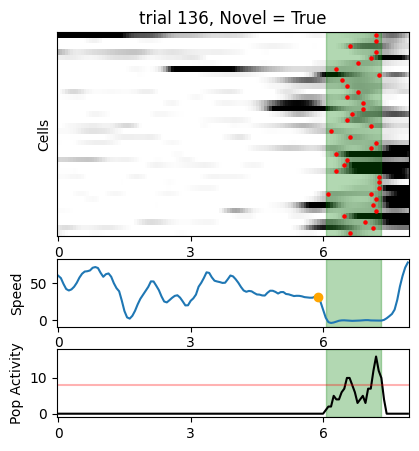

In [172]:
cond_key = 'ctrl'
mouse = ctrl_mice[1]
day = 1
#  1, 1, 106
# # 0, 1, trial 129

# cond_key = 'cre'
# mouse = ko_mice[3]
# day = 1
# 6, 1, trial 129
# 1, 1, 95
#  3, 1, 119

with open(hse_dict[cond_key][day][mouse], 'rb') as file:
    hse = pickle.load(file)

nov_trials = np.argwhere(hse.trial_info['LR']==hse.novel_arm).ravel()
for trial in nov_trials:
    fig = plot_single_trial_replay(hse, trial)

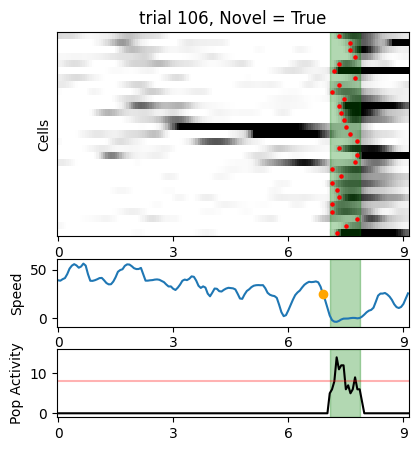

In [173]:
cond_key = 'ctrl'
mouse = ctrl_mice[1]
day = 1
trial = 106

with open(hse_dict[cond_key][day][mouse], 'rb') as file:
    hse = pickle.load(file)

fig, event_mask = plot_single_trial_replay(hse, trial)
fig.savefig(figdir / f"{mouse}_day{day}_trial{trial}_novel.pdf")

In [174]:
#  find cells that partipate and plot across day coding
cell_ids = np.argwhere(event_mask).ravel()
common_roi_mapping = u.common_rois_adjust(mouse, [1,2])
tracked_cells = common_roi_mapping[1,:]
tracked_reactivated_cells = []
for cell in cell_ids:
    ind = np.argwhere(cell==tracked_cells)
    if ind.shape[0]>0:
        tracked_reactivated_cells.append(ind[0][0])

sess = u.single_mouse_concat_sessions(mouse, [1,2], trial_mat_keys=['F_dff'], timeseries_keys=['F_dff'])
tmat= sess.trial_matrices['F_dff'][:,:,tracked_reactivated_cells]

30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel


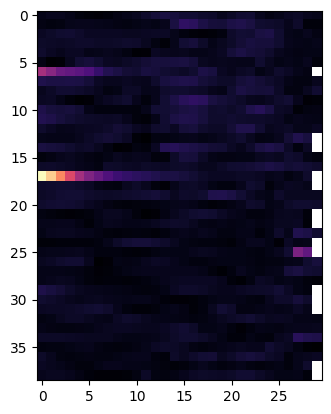

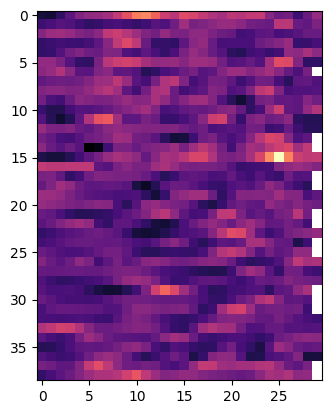

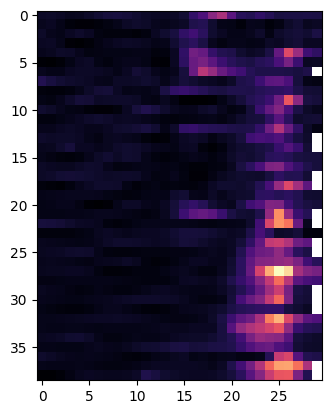

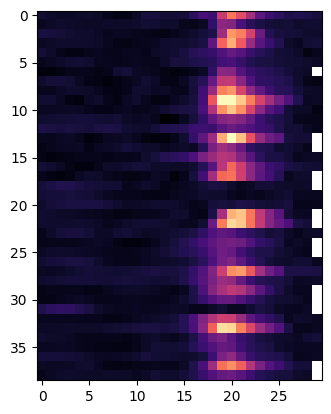

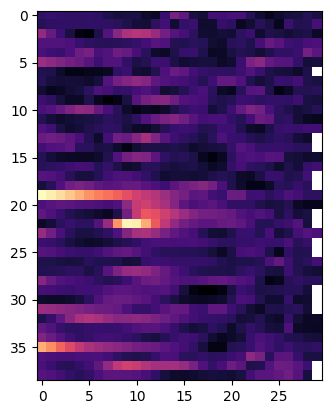

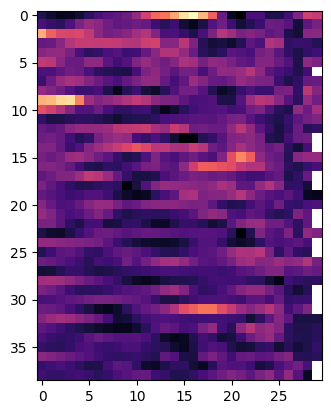

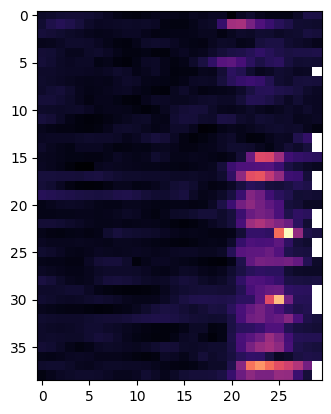

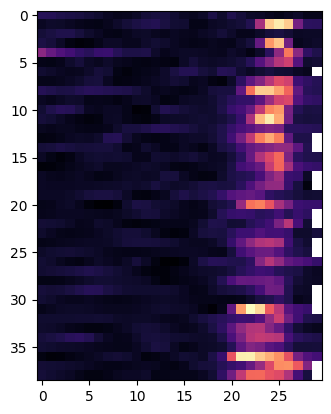

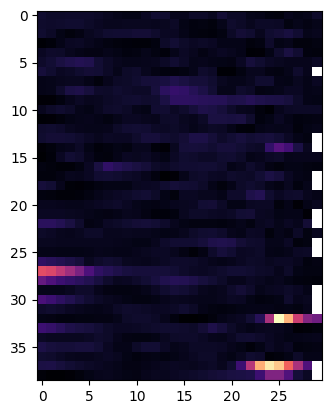

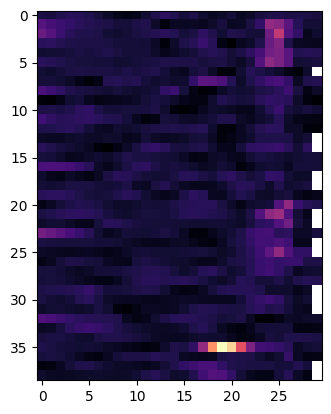

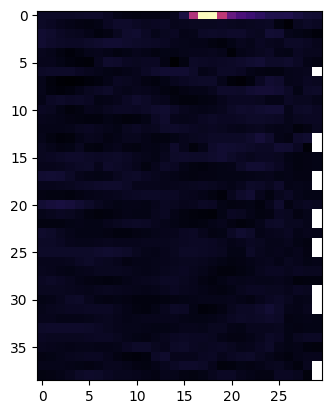

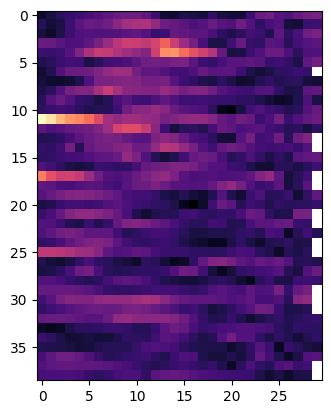

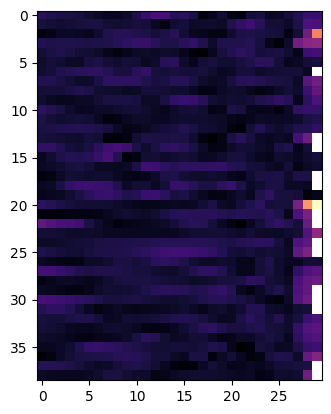

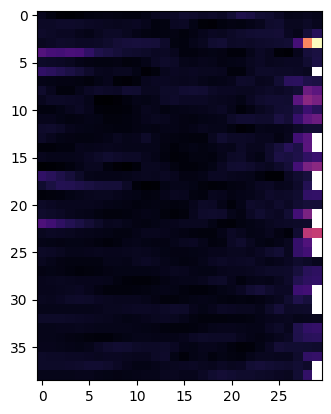

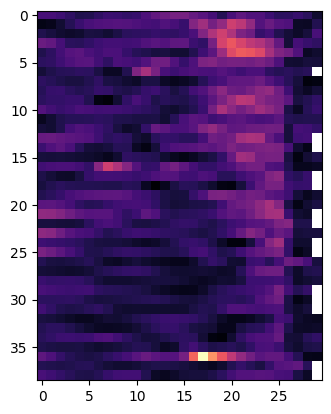

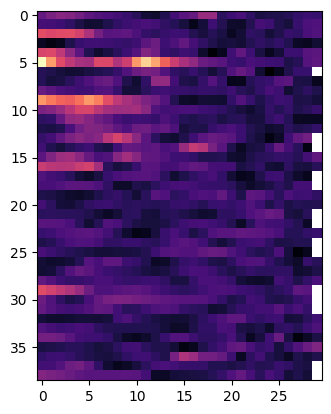

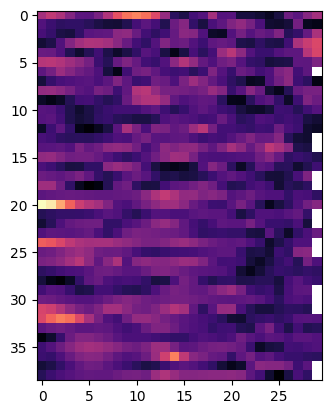

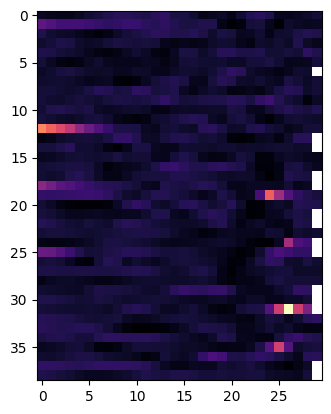

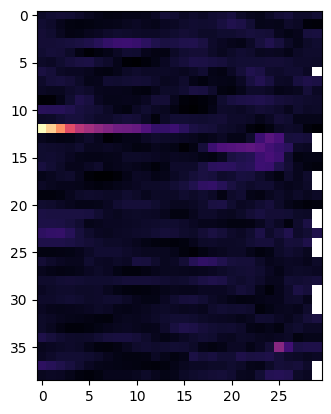

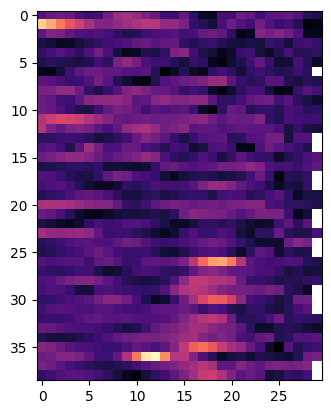

In [175]:
for cell in tracked_reactivated_cells:

    cell_mat = sess.trial_matrices['F_dff'][:,:,cell][sess.trial_info['LR']==sess.novel_arm,:]
    fig, ax= plt.subplots()
    ax.imshow(cell_mat, cmap='magma')

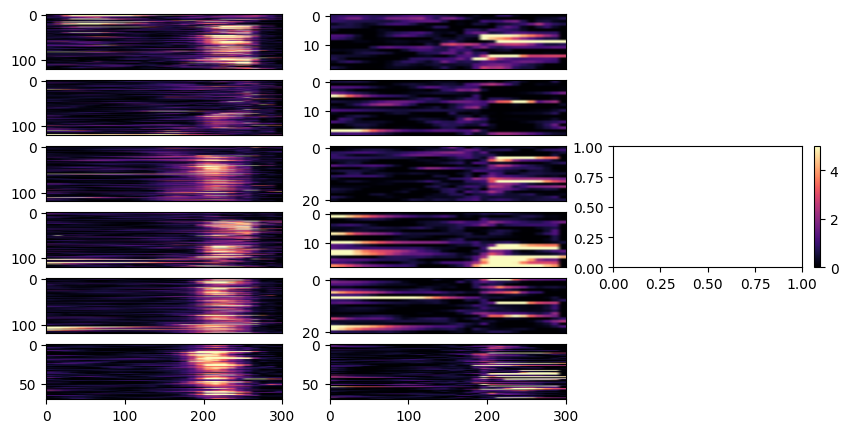

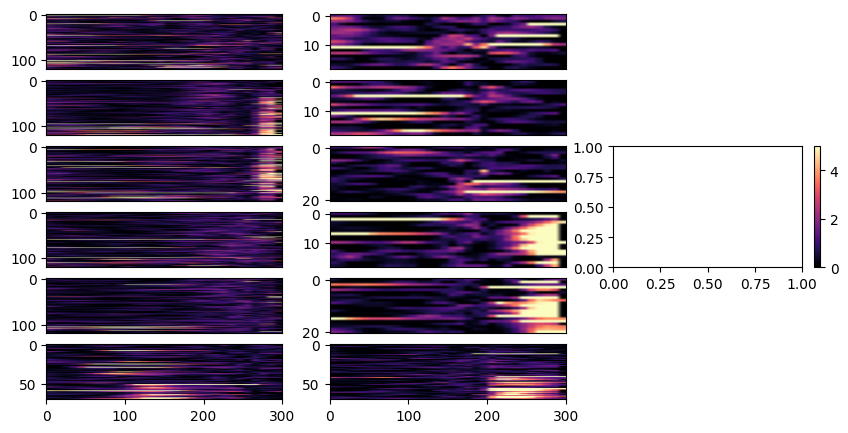

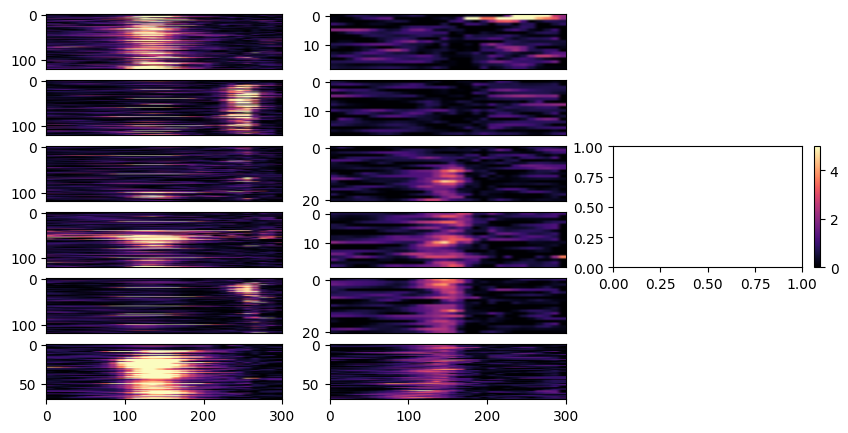

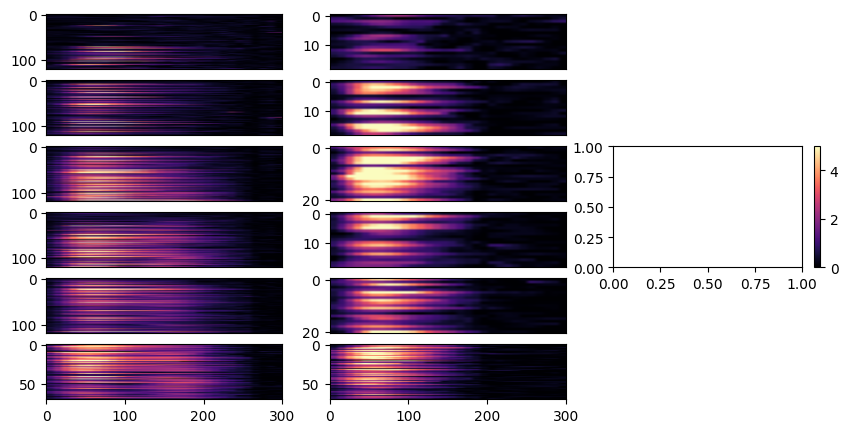

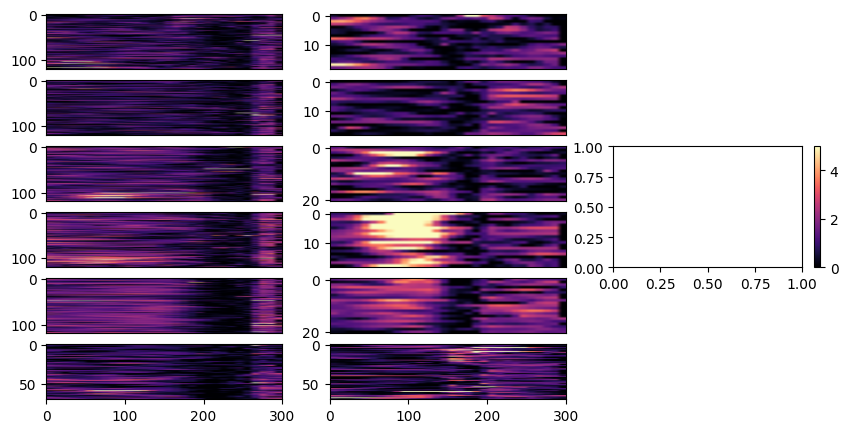

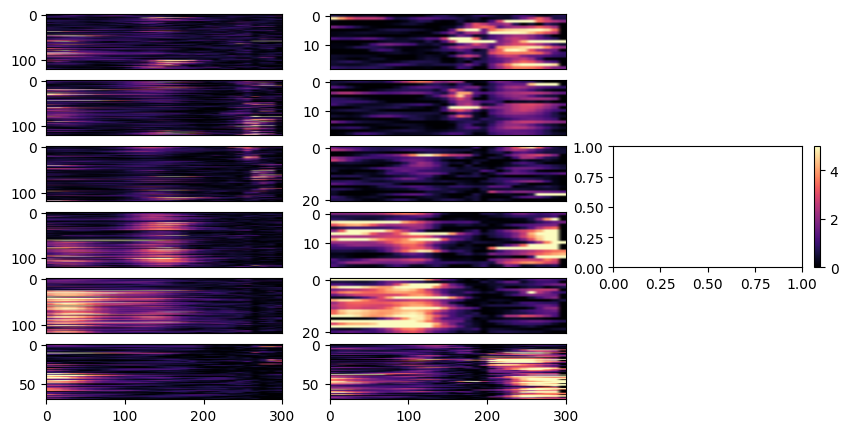

In [154]:
for cell in tracked_reactivated_cells:  
    fig, axs = stx.place_cell_vis.plot_cell_across_days(sess, cell, plot_roi=False)

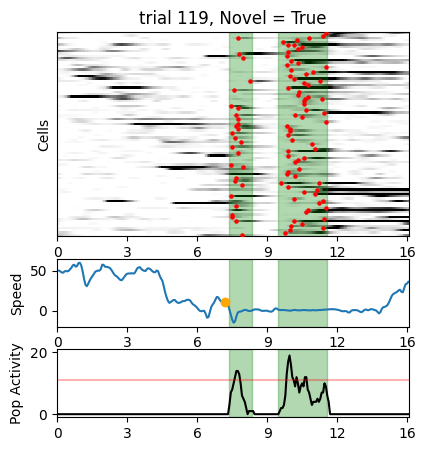

In [ ]:
cond_key = 'cre'
mouse = ko_mice[3]
day = 1

with open(hse_dict[cond_key][day][mouse], 'rb') as file:
    hse = pickle.load(file)

fig = plot_single_trial_replay(hse, 119)
fig.savefig(figdir / f"{mouse}_day{day}_trial119_novel.pdf")

In [57]:

df['tt_corr_z'] = np.arctanh(df['tt_corr'])
df['tt_corr_nan']= 1.*np.isnan(df['tt_corr'])
df_pos = df.loc[df['activated']==True].groupby(['condition','hse_day', 'tt_day', 'ttype', 'mouse']).mean().reset_index()

df_neg = df.loc[df['activated']==False].groupby(['condition','hse_day', 'tt_day', 'ttype', 'mouse']).mean().reset_index()
df_pos['tt_corr_diff'] = df_pos['tt_corr_z']-df_neg['tt_corr_z']

In [58]:
(df_pos['mouse']==ctrl_mice[-1]).sum()

np.int64(14)

In [63]:
mouse_include = []
for mouse in df_pos['mouse'].unique():
    if (df_pos['mouse']==mouse).sum()> 20:
        mouse_include.append(mouse)
print(mouse_include)
df_pos = df_pos[df_pos['mouse'].isin(mouse_include)]
df = df[df['mouse'].isin(mouse_include)]

['4467975.1', '4467975.2', '4467975.3', '4467975.4', '4467975.5', 'Cre9', '4467331.1', '4467331.2', '4467332.1', '4467332.2', '4467333.1', 'mCherry7', 'mCherry8']


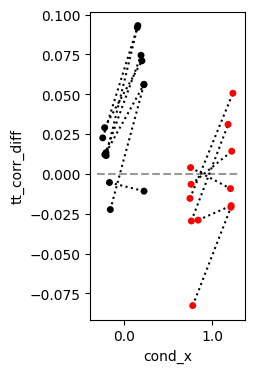

In [64]:
tmp_df = df_pos.groupby(['condition', 'mouse', 'ttype']).mean().reset_index()
tmp_df['cond_x'] = 1.*(tmp_df['condition']=='cre')

fig, ax = plt.subplots(figsize=[2,4])
sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='ctrl'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['black', 'black'],
              legend=False,
              ax=ax)

sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='cre'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['red', 'red'],
              legend=False,
              ax=ax)
for d in [0,2]:
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
ax.hlines(0,-.3, 1.3, linestyle='--', color='black', alpha=.4)


In [43]:
sess = u.load_single_day(ctrl_mice[0],0)
rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

df['cell_argmax_rz_centered']=np.nan
for cond, mice in zip(('ctrl', 'cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
                        
        if cond=='ctrl':
            novel_arm = stx.ymaze_sess_deets.CTRL_sessions[mouse][day]['novel_arm']
        else:
            novel_arm = stx.ymaze_sess_deets.KO_sessions[mouse][day]['novel_arm']

        if novel_arm == 1: 
            rz_nov = rz_late
            rz_fam = rz_early
        else: 
            rz_nov = rz_early
            rz_fam = rz_late

        for ttype in ('nov', 'fam'):
            if ttype == 'nov':
                rz = rz_nov
            else:
                rz = rz_fam
            mask = (df['mouse']==mouse) * (df['ttype']==ttype)
            df.loc[mask, 'cell_argmax_rz_centered'] = df['cell_argmax'] - rz[0]

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


<Axes: xlabel='cell_argmax_rz_centered', ylabel='Proportion'>

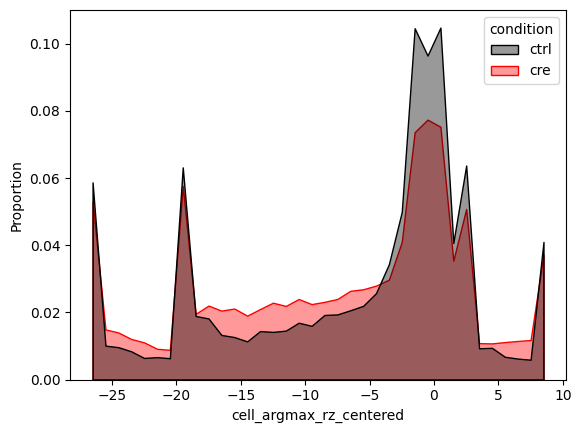

In [49]:
fig, ax = plt.subplots()
sns.histplot(data=df.loc[df['activated']==True],
             x='cell_argmax_rz_centered',
             hue='condition',
             hue_order=['ctrl', 'cre'],
             palette=['black', 'red'], 
             element='poly',
             stat='proportion', common_norm=False, fill=True, alpha=.4, binwidth=1, ax=ax)


In [50]:
# for each mouse
rows = []
for cond, mice in zip(('ctrl', 'cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(5):                      
            
            if cond=='ctrl':
                novel_arm = stx.ymaze_sess_deets.CTRL_sessions[mouse][0]['novel_arm']
            else:
                novel_arm = stx.ymaze_sess_deets.KO_sessions[mouse][0]['novel_arm']

            if novel_arm == 1: 
                rz_nov = rz_late
                rz_fam = rz_early
            else: 
                rz_nov = rz_early
                rz_fam = rz_late

            for ttype in ('nov', 'fam'):
                if ttype == 'nov':
                    rz = rz_nov
                else:
                    rz = rz_fam


                mask = (df['mouse']==mouse) * (df['ttype']==ttype) * (df['hse_day']==day)
                # positively correlated
                tmp_df = df.loc[(df['activated']==True)*mask]
                prop_posreward = (1.*((tmp_df['cell_argmax_rz_centered']<=1) * (tmp_df['cell_argmax_rz_centered']>=-5))).mean()

                # rows.append({'condition': cond,
                #              'mouse': mouse, 
                #              'hse_day': day,
                #              'ttype': ttype,
                #             #  'positive': True,
                #              'prop_reward': prop_reward})

                tmp_df = df.loc[(df['activated']==False)*mask]
                prop_negreward = (1.*((tmp_df['cell_argmax_rz_centered']<=1) * (tmp_df['cell_argmax_rz_centered']>=-5))).mean()

                rows.append({'condition': cond,
                             'mouse': mouse, 
                             'hse_day': day,
                             'ttype': ttype,
                             'prop_reward': prop_posreward,
                             'prop_reward_diff': prop_posreward-prop_negreward})


reward_frac_df = pd.DataFrame(rows)

<Axes: xlabel='hse_day', ylabel='prop_reward'>

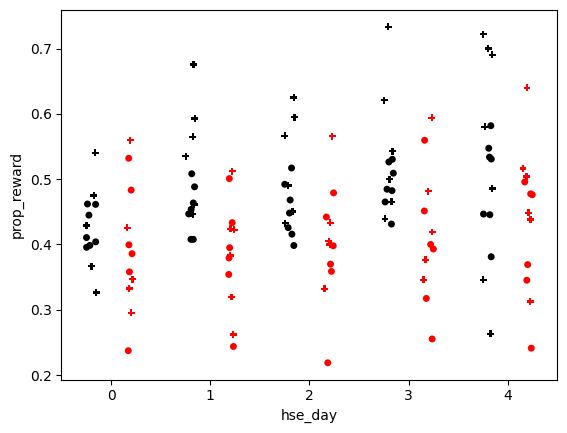

In [51]:
sns.stripplot(data = reward_frac_df.loc[(reward_frac_df['ttype']=='fam')],
              x='hse_day',
              y='prop_reward',
              hue='condition',
              hue_order=['ctrl','cre'],
              palette=['black','red'], legend=False,
              dodge=True)


sns.stripplot(data = reward_frac_df.loc[(reward_frac_df['ttype']=='nov')],
              x='hse_day',
              y='prop_reward',
              hue='condition',
              hue_order=['ctrl','cre'],
              palette=['black','red'],
              marker='P', legend=False,
              dodge=True)

In [40]:
df_grouped = df.groupby(['condition','hse_day', 'tt_day', 'ttype', 'mouse', 'activated']).mean().reset_index()


Text(0.5, 1.0, 'Cre: Nov')

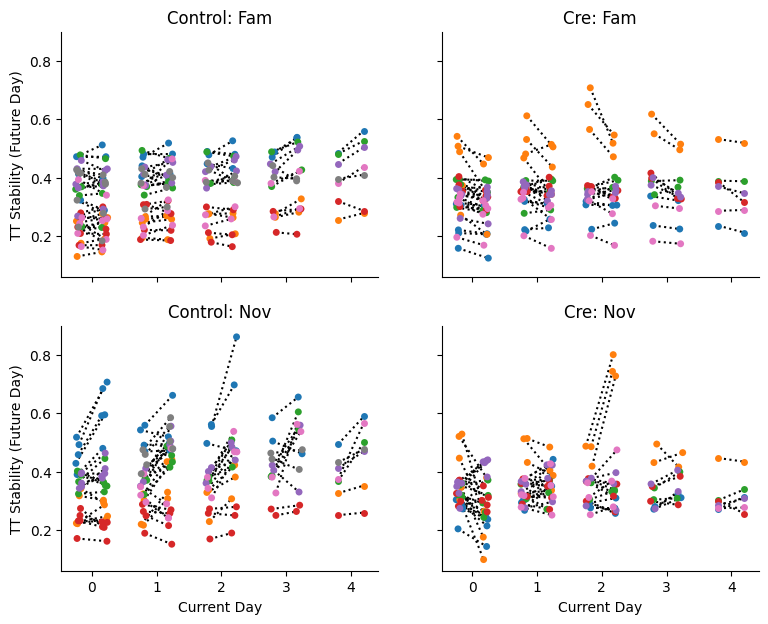

In [42]:
fig, ax = plt.subplots(2,2, figsize=(9,7), sharex=True, sharey=True)

for k, ttype in enumerate(['fam','nov']):
    old_ind = 0
    for i, mouse in enumerate(ctrl_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
            
        

        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr_z', 
                            hue='activated',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,0])
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,0].collections[d].get_offsets(), ax[k,0].collections[d+1].get_offsets()):
                ax[k,0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
        


    old_ind = 0
    for i, mouse in enumerate(ko_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='cre') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr_z', 
                            hue='activated',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,1])
        
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,1].collections[d].get_offsets(), ax[k,1].collections[d+1].get_offsets()):
                ax[k,1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Current Day')
    a.set_ylabel('TT Stability (Future Day)')
ax[0,0].set_title('Control: Fam')
ax[0,1].set_title('Cre: Fam')
ax[1,0].set_title('Control: Nov')
ax[1,1].set_title('Cre: Nov')
